<a href="https://colab.research.google.com/github/LUKASZCOM/LICENCJAT/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CZYSTE DANE

In [ ]:
## Import bibliotek
import numpy as np
import time
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, InputLayer
from tensorflow.keras.utils import to_categorical

In [ ]:
## Wgranie zbioru CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
class_name = ['Samolot', 'Samochód', 'Ptak', 'Kot', 'Jeleń',
               'Pies', 'Żaba', 'Koń', 'Statek', 'Ciężarówka']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
## Tworzenie architektury MLP
def mlp_model():
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
## Tworzenie naszego modelu MLP
model = mlp_model()
model.summary()
start_time = time.time()
mlp_clean = model.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

In [ ]:
results = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss = results[0]
global_acc = results[1]
print(global_acc)
print(global_loss)

0.5055999755859375
1.4350982904434204


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (Clean MLP)
training_accuracy = mlp_clean.history['accuracy']
training_loss = mlp_clean.history['loss']
validation_accuracy = mlp_clean.history['val_accuracy']
validation_loss = mlp_clean.history['val_loss']

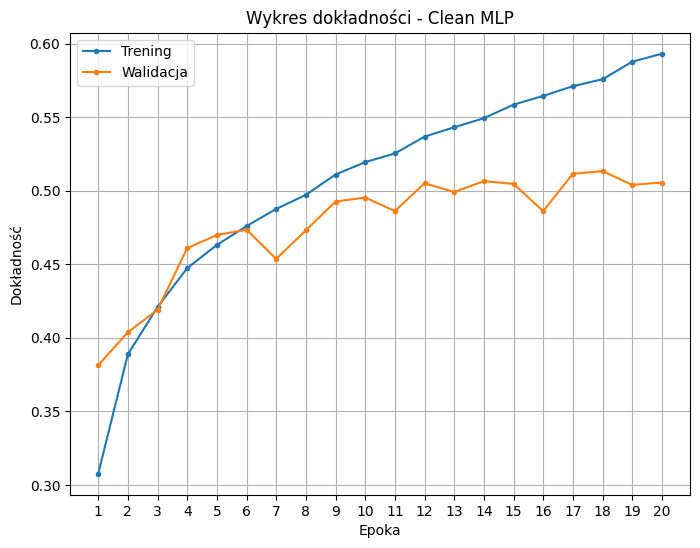

In [ ]:
## Wykres dokładności (Clean MLP)
epochs_num = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num, training_accuracy, label='Trening', marker='.')
plt.plot(epochs_num, validation_accuracy, label='Walidacja', marker='.')

plt.title('Wykres dokładności - Clean MLP')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num)
plt.legend()
plt.grid(True)


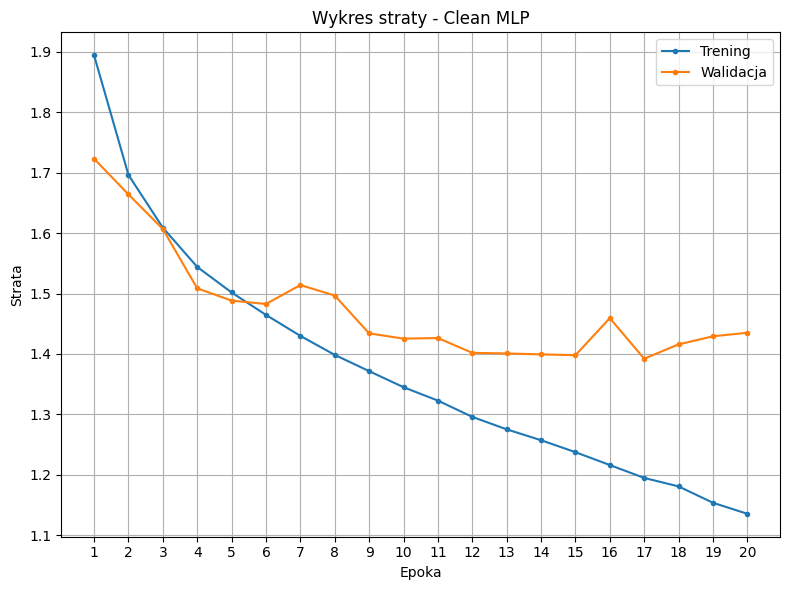

In [ ]:
## Wykres straty (Clean MLP)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num, training_loss, label='Trening', marker='.')
plt.plot(epochs_num, validation_loss, label='Walidacja', marker='.')


plt.title('Wykres straty - Clean MLP')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- RAPORT SZCZEGÓŁOWY - Clean MLP ---
              precision    recall  f1-score   support

     Samolot       0.59      0.53      0.56      1000
    Samochód       0.63      0.65      0.64      1000
        Ptak       0.41      0.31      0.35      1000
         Kot       0.36      0.32      0.34      1000
       Jeleń       0.38      0.53      0.44      1000
        Pies       0.48      0.30      0.37      1000
        Żaba       0.53      0.56      0.55      1000
         Koń       0.50      0.62      0.55      1000
      Statek       0.62      0.64      0.63      1000
  Ciężarówka       0.56      0.60      0.58      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



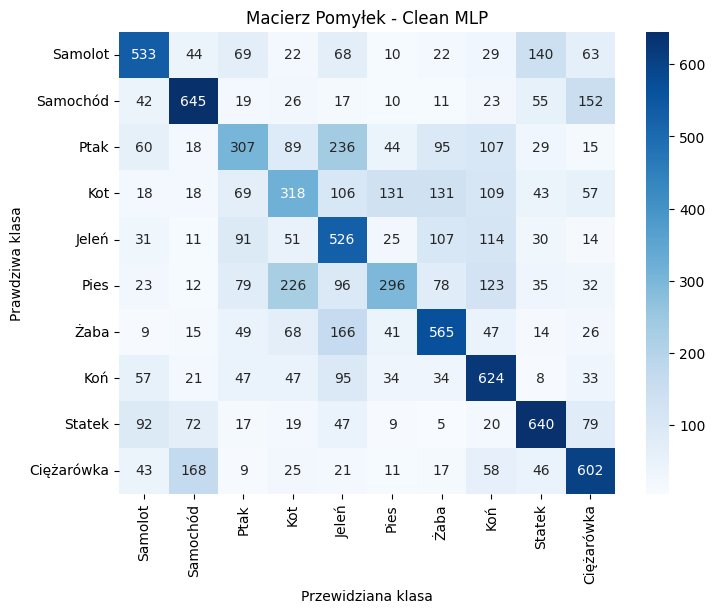

In [ ]:
## Sprawdzić to jeszcze zeby te parametry powyciagac - moze stad wezme klasy (2 najnizsze std)

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - Clean MLP ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - Clean MLP')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()


# LABEL FLIPPING


In [ ]:
def poison_label(y_train_cat, ratio):
    y_pois_label = np.copy(y_train_cat)
    labels = np.argmax(y_train_cat, axis=1)

    for a, b in [(1,9), (3,5)]:
        for c, d in [(a,b), (b,a)]:
            indx = np.where(labels == c)[0]
            wybor = np.random.choice(indx, int(len(indx) * ratio), replace=False)
            y_pois_label[wybor, :] = 0
            y_pois_label[wybor, d] = 1
    return y_pois_label

### 10%

In [ ]:
## Tworzenie naszego modelu MLP
y_train_poisoned_10 = poison_label(y_train_cat, ratio=0.1)
model = mlp_model()
model.summary()
start_time = time.time()
mlp_10 = model.fit(
    x_train, y_train_poisoned_10,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3100 - loss: 1.8883 - val_accuracy: 0.3721 - val_loss: 1.7388
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3797 - loss: 1.7123 - val_accuracy: 0.3949 - val_loss: 1.6728
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4053 - loss: 1.6307 - val_accuracy: 0.4242 - val_loss: 1.6285
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4313 - loss: 1.5661 - val_accuracy: 0.4341 - val_loss: 1.6003
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4463 - loss: 1.5221 - val_accuracy: 0.4364 - val_loss: 1.5534
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4621 - loss: 1.4874 - val_accuracy: 0.4681 - val_loss: 1.4915
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4693 - loss: 1.4609 - val_accuracy: 0.4466 - val_loss: 1.5330
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4816 - loss: 1.4326 - val_accuracy: 0.

In [ ]:
results_10 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_10 = results_10[0]
global_acc_10 = results_10[1]
print(global_acc_10)
print(global_loss_10)

0.5135999917984009
1.397839069366455


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (MLP 10%)
training_accuracy_10 = mlp_10.history['accuracy']
training_loss_10 = mlp_10.history['loss']
validation_accuracy_10 = mlp_10.history['val_accuracy']
validation_loss_10 = mlp_10.history['val_loss']

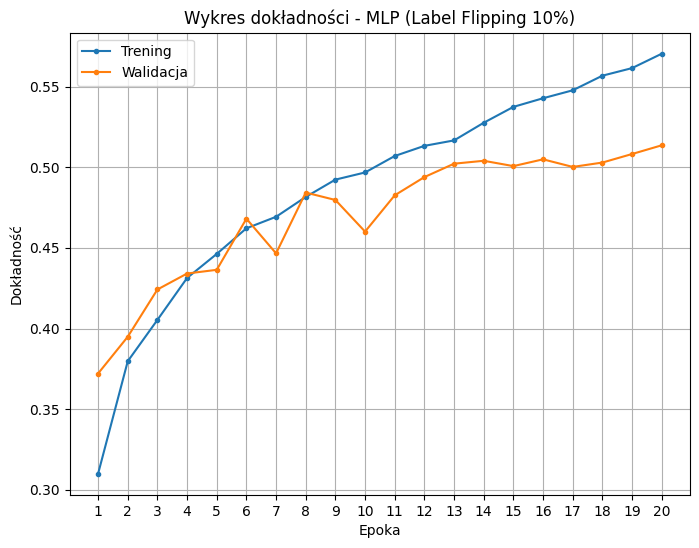

In [ ]:
## Wykres dokładności (MLP 10%)
epochs_num_10 = range(1, len(training_accuracy_10) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num_10, training_accuracy_10, label='Trening', marker='.')
plt.plot(epochs_num_10, validation_accuracy_10, label='Walidacja', marker='.')

plt.title('Wykres dokładności - MLP (Label Flipping 10%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num_10)
plt.legend()
plt.grid(True)

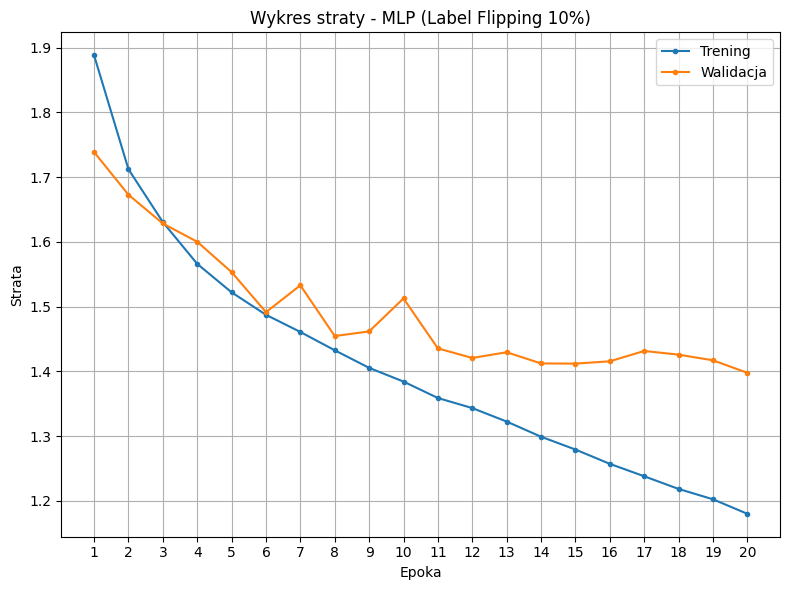

In [ ]:
## Wykres straty (MLP 10%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_10, training_loss_10, label='Trening', marker='.')
plt.plot(epochs_num_10, validation_loss_10, label='Walidacja', marker='.')


plt.title('Wykres straty - MLP (Label Flipping 10%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num_10)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

--- RAPORT SZCZEGÓŁOWY - MLP (Label Flipping 10%) ---
              precision    recall  f1-score   support

     Samolot       0.62      0.55      0.58      1000
    Samochód       0.64      0.58      0.61      1000
        Ptak       0.40      0.43      0.41      1000
         Kot       0.35      0.40      0.37      1000
       Jeleń       0.49      0.34      0.40      1000
        Pies       0.46      0.32      0.37      1000
        Żaba       0.50      0.65      0.57      1000
         Koń       0.51      0.66      0.57      1000
      Statek       0.68      0.63      0.65      1000
  Ciężarówka       0.54      0.57      0.56      1000

    accuracy                           0.51     10000
   macro avg       0.52      0.51      0.51     10000
weighted avg       0.52      0.51      0.51     10000



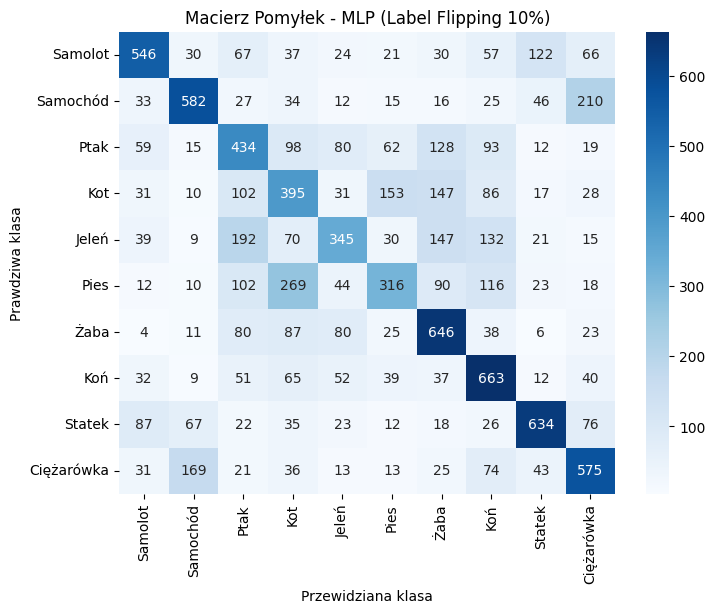

In [ ]:
## Macierz pomyłek i raport szczegółowy
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - MLP (Label Flipping 10%) ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - MLP (Label Flipping 10%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 20%

In [ ]:
## Tworzenie naszego modelu MLP
y_train_poisoned_20 = poison_label(y_train_cat, ratio=0.2)
model = mlp_model()
model.summary()
start_time = time.time()
mlp_20 = model.fit(
    x_train, y_train_poisoned_20,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2947 - loss: 1.9063 - val_accuracy: 0.3675 - val_loss: 1.7463
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3697 - loss: 1.7232 - val_accuracy: 0.3968 - val_loss: 1.6480
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3997 - loss: 1.6345 - val_accuracy: 0.4302 - val_loss: 1.6017
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4197 - loss: 1.5794 - val_accuracy: 0.4248 - val_loss: 1.5980
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4347 - loss: 1.5443 - val_accuracy: 0.4595 - val_loss: 1.5105
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4455 - loss: 1.5085 - val_accuracy: 0.4543 - val_loss: 1.5160
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4557 - loss: 1.4812 - val_accuracy: 0.4650 - val_loss: 1.4747
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4645 - loss: 1.4550 - val_accuracy: 0.

In [ ]:
results_20 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_20 = results_20[0]
global_acc_20 = results_20[1]
print(global_acc_20)
print(global_loss_20)

0.4936999976634979
1.4667893648147583


In [ ]:
training_accuracy_20 = mlp_20.history['accuracy']
training_loss_20 = mlp_20.history['loss']
validation_accuracy_20 = mlp_20.history['val_accuracy']
validation_loss_20 = mlp_20.history['val_loss']

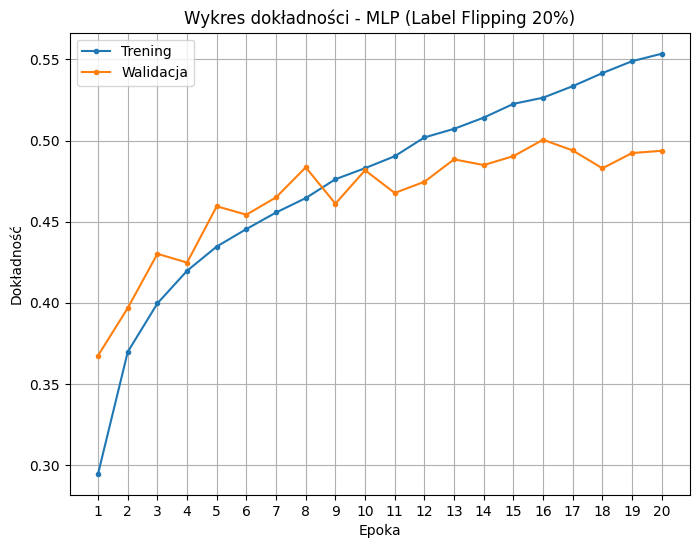

In [ ]:
## Wykres dokładności (MLP 20%)
epochs_num_20 = range(1, len(training_accuracy_20) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num_20, training_accuracy_20, label='Trening', marker='.')
plt.plot(epochs_num_20, validation_accuracy_20, label='Walidacja', marker='.')

plt.title('Wykres dokładności - MLP (Label Flipping 20%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num_20)
plt.legend()
plt.grid(True)

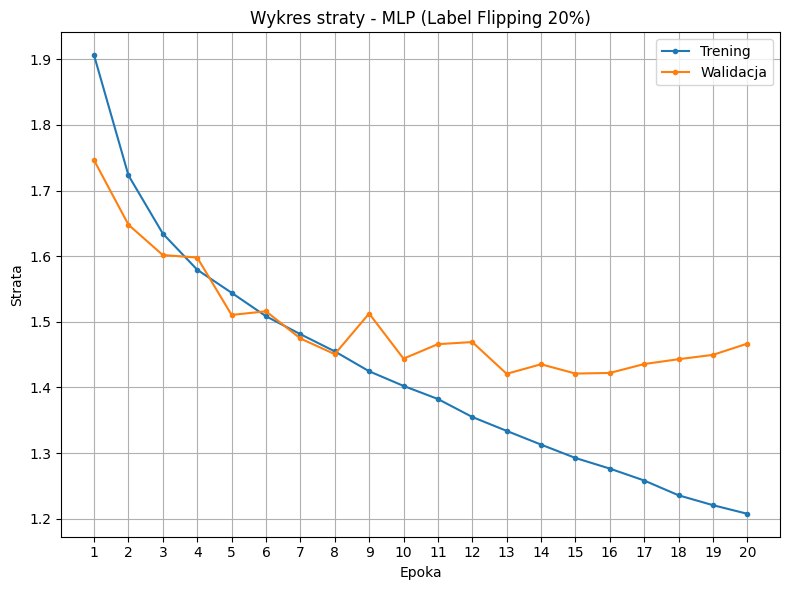

In [ ]:
## Wykres straty (MLP 20%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_20, training_loss_20, label='Trening', marker='.')
plt.plot(epochs_num_20, validation_loss_20, label='Walidacja', marker='.')


plt.title('Wykres straty - MLP (Label Flipping 20%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num_20)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

--- RAPORT SZCZEGÓŁOWY - MLP (Label Flipping 20%) ---
              precision    recall  f1-score   support

     Samolot       0.64      0.56      0.60      1000
    Samochód       0.58      0.57      0.58      1000
        Ptak       0.38      0.36      0.37      1000
         Kot       0.36      0.18      0.24      1000
       Jeleń       0.43      0.43      0.43      1000
        Pies       0.43      0.40      0.41      1000
        Żaba       0.39      0.73      0.51      1000
         Koń       0.62      0.52      0.57      1000
      Statek       0.67      0.60      0.64      1000
  Ciężarówka       0.50      0.58      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



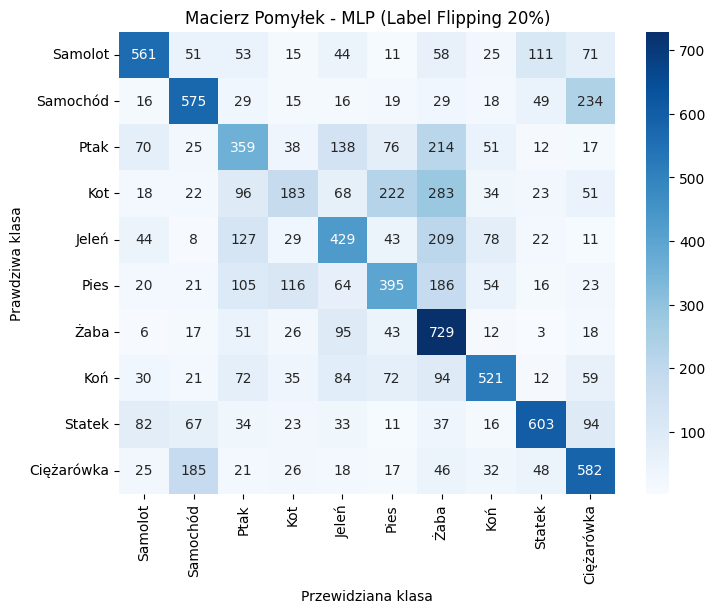

In [ ]:
## Macierz pomyłek i raport szczegółowy (MLP 20%)
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - MLP (Label Flipping 20%) ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - MLP (Label Flipping 20%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 30%


In [ ]:
## Tworzenie naszego modelu MLP
y_train_poisoned_30 = poison_label(y_train_cat, ratio=0.3)
model = mlp_model()
model.summary()
start_time = time.time()
mlp_30 = model.fit(
    x_train, y_train_poisoned_30,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2887 - loss: 1.9180 - val_accuracy: 0.3684 - val_loss: 1.7745
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3631 - loss: 1.7245 - val_accuracy: 0.4078 - val_loss: 1.6449
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3916 - loss: 1.6409 - val_accuracy: 0.4266 - val_loss: 1.5922
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4109 - loss: 1.5911 - val_accuracy: 0.4209 - val_loss: 1.5907
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4245 - loss: 1.5462 - val_accuracy: 0.4410 - val_loss: 1.5457
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4371 - loss: 1.5126 - val_accuracy: 0.4456 - val_loss: 1.5313
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4444 - loss: 1.4813 - val_accuracy: 0.4592 - val_loss: 1.4889
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4551 - loss: 1.4567 - val_accuracy: 0.

In [ ]:
results_30 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_30 = results_30[0]
global_acc_30 = results_30[1]
print(global_acc_30)
print(global_loss_30)

0.4943000078201294
1.4205580949783325


In [ ]:
training_accuracy_30 = mlp_30.history['accuracy']
training_loss_30 = mlp_30.history['loss']
validation_accuracy_30 = mlp_30.history['val_accuracy']
validation_loss_30 = mlp_30.history['val_loss']

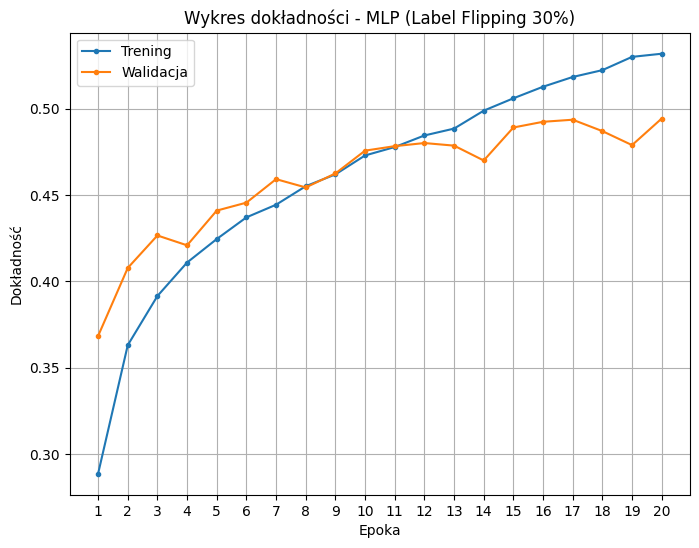

In [ ]:
## Wykres dokładności (MLP 30%)
epochs_num_30 = range(1, len(training_accuracy_30) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num_30, training_accuracy_30, label='Trening', marker='.')
plt.plot(epochs_num_30, validation_accuracy_30, label='Walidacja', marker='.')

plt.title('Wykres dokładności - MLP (Label Flipping 30%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num_30)
plt.legend()
plt.grid(True)

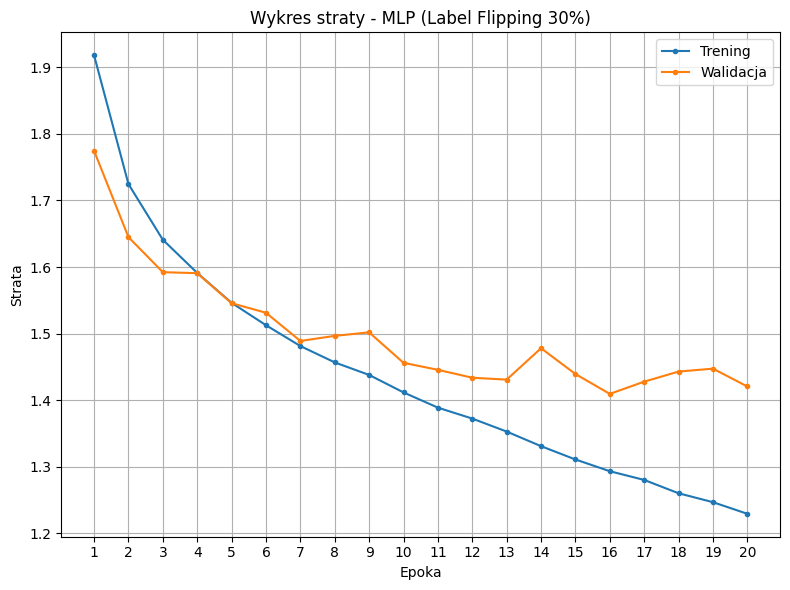

In [ ]:
## Wykres straty (MLP 30%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_30, training_loss_30, label='Trening', marker='.')
plt.plot(epochs_num_30, validation_loss_30, label='Walidacja', marker='.')

plt.title('Wykres straty - MLP (Label Flipping 30%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num_30)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- RAPORT SZCZEGÓŁOWY - MLP (Label Flipping 30%) ---
              precision    recall  f1-score   support

     Samolot       0.63      0.52      0.57      1000
    Samochód       0.60      0.50      0.54      1000
        Ptak       0.38      0.41      0.39      1000
         Kot       0.33      0.41      0.36      1000
       Jeleń       0.49      0.37      0.42      1000
        Pies       0.39      0.35      0.37      1000
        Żaba       0.48      0.60      0.53      1000
         Koń       0.59      0.56      0.58      1000
      Statek       0.59      0.71      0.64      1000
  Ciężarówka       0.54      0.53      0.53      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



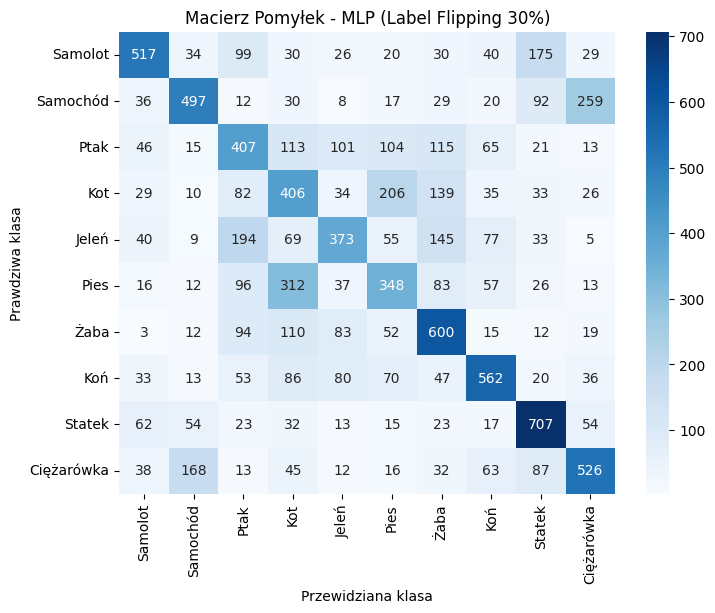

In [ ]:
## Macierz pomyłek i raport szczegółowy (MLP 30%)
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - MLP (Label Flipping 30%) ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - MLP (Label Flipping 30%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()